Degree: 1 Train Error: 106.99214822318092 Test Error: 107.44617011213933
Degree: 2 Train Error: 65.1821629183917 Test Error: 65.79720717027799
Degree: 3 Train Error: 64.00073710128154 Test Error: 65.3717484421088
Degree: 4 Train Error: 63.4189971192499 Test Error: 64.93921265704577
Degree: 5 Train Error: 62.8097332991691 Test Error: 64.43028184511246


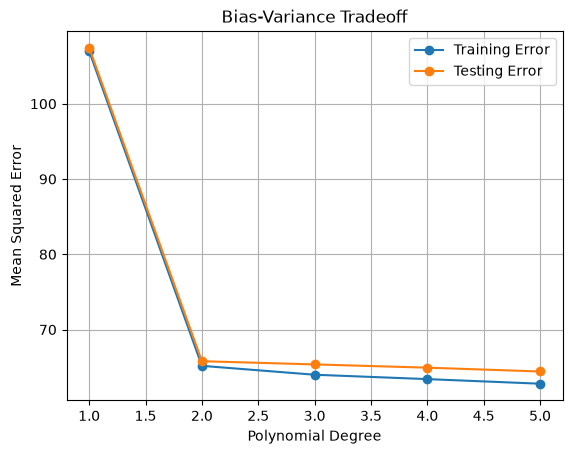

In [1]:
# 11. Implement Bias-Variance Tradeoff Visualization
# Dataset: Synthetic Polynomial Dataset
# Given Dataset: Work and Lifestyle Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Load dataset
df = pd.read_csv("Synthetic Polynomial Dataset.csv")

# Independent variables
X = df[[
    'avg_work_hours_per_day',
    'avg_rest_hours_per_day',
    'avg_sleep_hours_per_day',
    'avg_exercise_hours_per_day'
]]

# Target variable
y = df['age_at_death']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Different polynomial degrees
degrees = [1, 2, 3, 4, 5]

train_errors = []
test_errors = []

# Train models
for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Calculate errors
    train_errors.append(
        mean_squared_error(y_train, train_pred)
    )

    test_errors.append(
        mean_squared_error(y_test, test_pred)
    )

# Display errors
for i in range(len(degrees)):
    print(
        "Degree:", degrees[i],
        "Train Error:", train_errors[i],
        "Test Error:", test_errors[i]
    )

# Visualization
plt.plot(degrees, train_errors, marker='o', label="Training Error")
plt.plot(degrees, test_errors, marker='o', label="Testing Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Tradeoff")
plt.legend()
plt.grid()
plt.show()